# Titanic Passenger Survival: Visual Analysis and Reporting

- **Course:** ANA 500 Python for Data Science
- **Assignment:** Micro-Project 2
- **Name:** Travis James
- **Dataset:** Titanic passenger data (cleaned in Micro-Project 1)
- **Scope:** Steps 1 through 4 of the data science process (Acquire,
  Prepare, Analyze, Report) using Matplotlib and Seaborn
- **Micro-Project 1:** https://github.com/OrangeJoe0421/ANA-500-MP1

---

## Problem Statement

Survival on the Titanic was not random. This project describes which passenger
characteristics (sex, ticket class, age, family situation, fare, and port of
embarkation) were associated with who lived and who died.

## Hypothesis

Women and passengers in higher ticket classes survived at higher rates than men
and passengers in lower ticket classes.

Micro-Project 1 prepared the data. This notebook tests the hypothesis visually,
backs each main pattern with a simple statistical check, and reports what the
evidence shows. To keep the analysis focused, the hypothesis is broken into
three testable parts:

| ID | Sub-hypothesis | Main visual |
|---|---|---|
| H1 | Women survived at a higher rate than men | Survival rate by sex |
| H2 | Survival rate falls from first to third class | Survival rate by class |
| H3 | The sex gap holds inside every class, so class and sex both matter | Sex by class heatmap |

Age, family size, fare, and port are treated as supporting variables that may
explain or complicate the main result.

---
# Step 1: Acquire

The main input is `titanic_clean.csv`, the output of Micro-Project 1. The raw
`titanic.csv` file is also loaded, because Step 2 revisits one cleaning
decision (the two missing `Embarked` values) using the original records.

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy.stats import chi2_contingency
from pathlib import Path


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 80)

In [7]:
# Load the cleaned file from Micro-Project 1 and the original raw file.
clean = pd.read_csv("titanic_clean.csv")
raw = pd.read_csv("titanic.csv")

print(f"Cleaned data: {clean.shape[0]:,} rows, {clean.shape[1]} columns")
print(f"Raw data    : {raw.shape[0]:,} rows, {raw.shape[1]} columns")

# CSV files do not store data types, so the category and nullable integer
# types set in Micro-Project 1 need to be restored after loading.
clean["Survived"] = clean["Survived"].astype("Int64")
for col in ["Sex", "Embarked", "Title", "Deck", "AgeGroup"]:
    clean[col] = clean[col].astype("category")

clean.head()

Cleaned data: 1,309 rows, 20 columns
Raw data    : 1,309 rows, 12 columns


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Name,Ticket,Title,AgeGroup,AgeWasMissing,FamilySize,IsAlone,HasCabin,Deck,FareLog,FareWasZero
0,1,0,3,male,22.0,1,0,7.2500,S,"Braund, Mr. Owen Harris",A/5 21171,Mr,Adult,False,2,0,0,U,2.110213,False
1,2,1,1,female,38.0,1,0,71.2833,C,"Cumings, Mrs. John Bradley (Florence Briggs Th...",PC 17599,Mrs,Adult,False,2,0,1,C,4.280593,False
2,3,1,3,female,26.0,0,0,7.9250,S,"Heikkinen, Miss. Laina",STON/O2. 3101282,Miss,Adult,False,1,1,0,U,2.188856,False
3,4,1,1,female,35.0,1,0,53.1000,S,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",113803,Mrs,Adult,False,2,0,1,C,3.990834,False
4,5,0,3,male,35.0,0,0,8.0500,S,"Allen, Mr. William Henry",373450,Mr,Adult,False,1,1,0,U,2.202765,False


In [8]:
# Quick integrity check that the file loaded matches what Micro-Project 1
# saved: same row count, unique IDs, and only Survived has blanks.
assert len(clean) == 1309, "Row count does not match Micro-Project 1"
assert clean["PassengerId"].is_unique, "PassengerId is not unique"
missing = clean.isna().sum()
assert set(missing[missing > 0].index) == {"Survived"}, "Unexpected blanks"
print("Cleaned data matches the Micro-Project 1 output.")

Cleaned data matches the Micro-Project 1 output.


---
# Step 2: Prepare

Most preparation was completed in Micro-Project 1. This step does three
things before analysis:

1. Revisits the `Embarked` imputation based on instructor feedback
2. Builds the analysis set of passengers with a known outcome
3. Adds readable labels and sets a consistent chart style

### 2a. Revisiting the two missing `Embarked` values

In Micro-Project 1 the two missing ports were filled with the overall mode
(S, Southampton). The feedback asked whether the shared ticket and cabin could
support a more specific imputation. The checks below test that.

In [9]:
# Pull the two passengers with no port from the raw file.
no_port = raw.loc[raw["Embarked"].isna(),
                  ["PassengerId", "Name", "Pclass", "Ticket", "Fare", "Cabin"]]
print(no_port.to_string(index=False))


ticket = no_port["Ticket"].iloc[0]
cabin = no_port["Cabin"].iloc[0]
print(f"\nPassengers on ticket {ticket}:", (raw["Ticket"] == ticket).sum())
print(f"Passengers in cabin {cabin}  :", (raw["Cabin"] == cabin).sum())

 PassengerId                                      Name  Pclass Ticket  Fare Cabin
          62                       Icard, Miss. Amelie       1 113572  80.0   B28
         830 Stone, Mrs. George Nelson (Martha Evelyn)       1 113572  80.0   B28

Passengers on ticket 113572: 2
Passengers in cabin B28  : 2


Both passengers share ticket 113572 and cabin B28, but no one else in the file
does, so there is no travel companion whose port can simply be copied. The
next best evidence is passengers who look like them: first class, a similar
ticket number, and a similar fare.

In [10]:
series_113 = raw["Ticket"].str.match(r"^113\d{3}$")
print("Ports for other 113xxx tickets:")
print(raw.loc[series_113 & raw["Embarked"].notna(), "Embarked"]
         .value_counts())

raw["TicketGroup"] = raw.groupby("Ticket")["Ticket"].transform("size")
raw["FarePerPerson"] = raw["Fare"] / raw["TicketGroup"]
first = raw[raw["Pclass"] == 1]
print("\nMedian first-class fare per person by port:")
print(first.groupby("Embarked")["FarePerPerson"].median().round(2))
similar = first["FarePerPerson"].between(35, 45)
print("\nPorts for first-class passengers paying 35 to 45 per person:")
print(first.loc[similar, "Embarked"].value_counts())

Ports for other 113xxx tickets:
Embarked
S    54
C    10
Name: count, dtype: int64

Median first-class fare per person by port:
Embarked
C    34.65
Q    30.00
S    26.55
Name: FarePerPerson, dtype: float64

Ports for first-class passengers paying 35 to 45 per person:
Embarked
C    45
S    27
Name: count, dtype: int64


**Decision:** the two lines of evidence point in different directions. Fare
per person leans toward Cherbourg (C), but only loosely, because first-class
fares from C and S overlap heavily. The ticket series is the stronger signal:
about 84% of other `113xxx` tickets (54 of 64) boarded at Southampton, and a
ticket number is tied to how and where the ticket was bought, while a fare
can be matched by passengers from any port. The two passengers are therefore
assigned **S** based on their ticket series.

The final value is the same as in Micro-Project 1, but it is now justified by
evidence specific to these passengers rather than the overall mode. The
imputation is recorded in a new flag column so it stays traceable.

In [11]:
# Apply the ticket-series imputation and flag the two rows.
fill_ids = no_port["PassengerId"]
clean["EmbarkedWasMissing"] = clean["PassengerId"].isin(fill_ids)
clean.loc[clean["EmbarkedWasMissing"], "Embarked"] = "S"
assert (clean.loc[clean["EmbarkedWasMissing"], "Embarked"] == "S").all()
print("Rows flagged as imputed Embarked:", clean["EmbarkedWasMissing"].sum())

Rows flagged as imputed Embarked: 2


### 2b. Build the analysis set

In [12]:
# Only the 891 passengers with a known outcome can test the hypothesis. The
# 418 holdout rows (blank Survived) are set aside, as planned in
# Micro-Project 1.
df = clean[clean["Survived"].notna()].copy()
df["Survived"] = df["Survived"].astype(int)
print(f"Analysis set: {len(df)} passengers")
print(f"Overall survival rate: {df['Survived'].mean():.1%}")

# Readable labels for chart axes and legends. The numeric and coded columns
# stay unchanged for calculations.
df["Outcome"] = df["Survived"].map({0: "Died", 1: "Survived"})
df["Class"] = df["Pclass"].map({1: "1st", 2: "2nd", 3: "3rd"})
df["Port"] = df["Embarked"].map(
    {"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"})
df["SexLabel"] = df["Sex"].astype(str).str.title()

# Fixed orders so every chart lists categories the same way.
CLASS_ORDER = ["1st", "2nd", "3rd"]
SEX_ORDER = ["Female", "Male"]
AGE_ORDER = ["Child", "Teen", "Adult", "MiddleAge", "Senior"]
PORT_ORDER = ["Cherbourg", "Queenstown", "Southampton"]

Analysis set: 891 passengers
Overall survival rate: 38.4%


### 2c. Chart style



In [13]:

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
OUTCOME_COLORS = {"Survived": BLUE, "Died": ORANGE}
SEX_COLORS = {"Female": BLUE, "Male": ORANGE}


sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": GRID,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid.axis": "y", "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.labelsize": 11,
})

# Every chart is also saved as a PNG for the slide deck.
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def label_bars(ax, fmt="{:.0%}", counts=None):
    
    for i, bar in enumerate(ax.patches):
        h = bar.get_height()
        if np.isnan(h):
            continue
        text = fmt.format(h)
        if counts is not None:
            text += f"\nn={counts[i]}"
        ax.annotate(text, (bar.get_x() + bar.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=9, color=INK,
                    xytext=(0, 3), textcoords="offset points")


def pct_axis(ax, top=1.0):
    # Format the y-axis as percentages with a little headroom for labels.
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylim(0, top)

---
# Step 3: Analyze

**Analytical techniques used**

- **Grouped survival rates** (bar charts): the share of each group that
  survived, compared against the overall rate of 38.4%
- **Two-way comparison** (heatmap): survival rate for every sex and class
  combination, to check whether one factor explains the other
- **Distributions** (histograms and box plots): how age and fare differ
  between passengers who lived and died
- **Chi-square test of independence**: a statistical check that each visual
  gap is too large to be explained by chance
- **Correlation matrix**: a compact view of which numeric features move with
  survival



### 3a. Baseline: overall survival

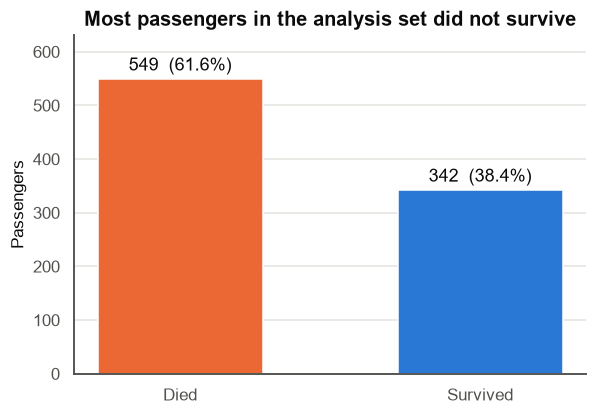

In [14]:
# Count how many passengers died and survived, and show it as a bar chart.
BASE = df["Survived"].mean()
outcome_counts = df["Outcome"].value_counts().reindex(["Died", "Survived"])

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(outcome_counts.index, outcome_counts.values,
       color=[ORANGE, BLUE], width=0.55)
for i, v in enumerate(outcome_counts.values):
    ax.annotate(f"{v}  ({v / len(df):.1%})", (i, v), ha="center",
                va="bottom", xytext=(0, 3), textcoords="offset points")
ax.set_title("Most passengers in the analysis set did not survive")
ax.set_ylabel("Passengers")
ax.set_ylim(0, outcome_counts.max() * 1.15)
fig.savefig(FIG_DIR / "01_overall.png")
plt.show()

**Observation:** 549 of 891 passengers (61.6%) died and 342 (38.4%) survived.
Any group whose survival rate is well above or below 38.4% stands out from the
baseline.

### 3b. H1 and H2: survival by sex and by ticket class

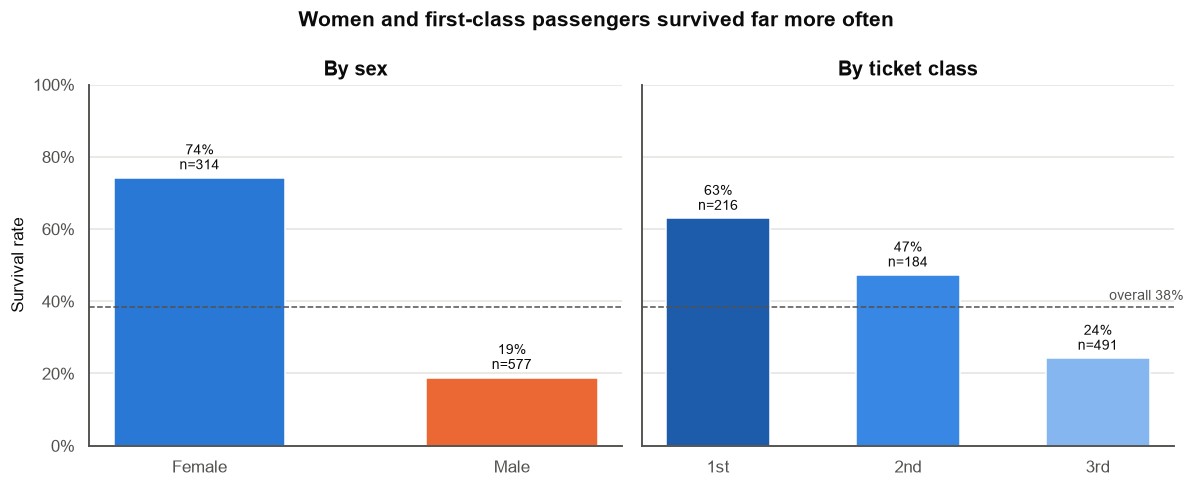

           mean  size
SexLabel             
Female    0.742   314
Male      0.189   577

        mean  size
Class             
1st    0.630   216
2nd    0.473   184
3rd    0.242   491


In [15]:

sex_rate = df.groupby("SexLabel")["Survived"].agg(["mean", "size"])
sex_rate = sex_rate.reindex(SEX_ORDER)
class_rate = df.groupby("Class")["Survived"].agg(["mean", "size"])
class_rate = class_rate.reindex(CLASS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

axes[0].bar(sex_rate.index, sex_rate["mean"],
            color=[SEX_COLORS[s] for s in sex_rate.index], width=0.55)
label_bars(axes[0], counts=sex_rate["size"].tolist())
axes[0].set_title("By sex")


axes[1].bar(class_rate.index, class_rate["mean"],
            color=["#1c5cab", "#3987e5", "#86b6ef"], width=0.55)
label_bars(axes[1], counts=class_rate["size"].tolist())
axes[1].set_title("By ticket class")

for ax in axes:
    ax.axhline(BASE, ls="--", lw=1, color=MUTED)
    pct_axis(ax, 1.0)
axes[0].set_ylabel("Survival rate")
axes[1].text(2.45, BASE + 0.02, "overall 38%", ha="right",
             fontsize=9, color=MUTED)
fig.suptitle("Women and first-class passengers survived far more often",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_sex_class.png")
plt.show()

print(sex_rate.assign(mean=sex_rate["mean"].round(3)))
print()
print(class_rate.assign(mean=class_rate["mean"].round(3)))

**Observation (H1):** 74.2% of women survived compared with 18.9% of men, a
gap of about 55 percentage points. Women were only 35% of the analysis set but
made up 68% of the survivors (233 of 342).

**Observation (H2):** survival falls steadily with class: 63.0% in first,
47.3% in second, and 24.2% in third. Third class was the largest group (491
passengers) and the only class below the overall rate.

### 3c. H3: does the sex gap hold inside every class?

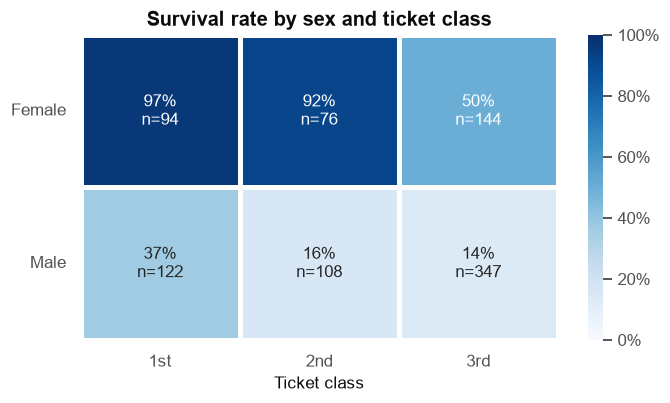

Class,1st,2nd,3rd
SexLabel,,,
Female,0.968,0.921,0.500
Male,0.369,0.157,0.135


In [16]:

rate = df.pivot_table(index="SexLabel", columns="Class", values="Survived",
                      aggfunc="mean").reindex(index=SEX_ORDER,
                                              columns=CLASS_ORDER)
size = df.pivot_table(index="SexLabel", columns="Class", values="Survived",
                      aggfunc="size").reindex(index=SEX_ORDER,
                                              columns=CLASS_ORDER)
annot = rate.map(lambda v: f"{v:.0%}") + "\nn=" + size.astype(str)

fig, ax = plt.subplots(figsize=(7, 3.6))
sns.heatmap(rate, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1,
            linewidths=2, linecolor="white",
            cbar_kws={"format": mtick.PercentFormatter(1.0)},
            annot_kws={"fontsize": 11}, ax=ax)
ax.grid(False)
ax.set_title("Survival rate by sex and ticket class")
ax.set_xlabel("Ticket class")
ax.set_ylabel("")
ax.tick_params(axis="y", rotation=0)
fig.savefig(FIG_DIR / "03_heatmap.png")
plt.show()

rate.round(3)

**Observation (H3):** women out-survived men in every class, and both sexes
did better in higher classes. The two factors stack:

- First- and second-class women survived at 97% and 92%.
- Third-class women survived at 50%, well below other women but still above
  first-class men (37%).
- Second- and third-class men were the worst off at 16% and 14%.

So class alone does not explain the sex gap, and sex alone does not explain
the class gap. Sex is the stronger factor, since the lowest female group
beats the highest male group.

### 3d. Statistical check: chi-square tests

In [17]:
def chi_square(col):
    table = pd.crosstab(df[col], df["Survived"])
    chi2, p, dof, _ = chi2_contingency(table)
    n = table.to_numpy().sum()
    v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    return {"variable": col, "chi2": round(chi2, 1), "dof": dof,
            "p_value": p, "cramers_v": round(v, 3)}


tests = pd.DataFrame([chi_square(c) for c in
                      ["Sex", "Pclass", "Title", "Port", "AgeGroup",
                       "IsAlone"]])
tests = tests.sort_values("cramers_v", ascending=False)
tests["p_value"] = tests["p_value"].map(lambda p: f"{p:.1e}")
tests

,variable,chi2,dof,p_value,cramers_v
2,Title,288.1,4,4.0e-61,0.569
0,Sex,260.7,1,1.2e-58,0.541
1,Pclass,102.9,2,4.5e-23,0.340
5,IsAlone,36.0,1,2.0e-09,0.201
3,Port,26.0,2,2.3e-06,0.171
4,AgeGroup,17.1,4,1.8e-03,0.139


**Observation:** every tested variable is associated with survival at far
below the usual 0.05 cutoff, but the strength differs a lot. Sex (V = 0.54)
and title are the strongest. Class
(V = 0.34) is next. Port, age group, and traveling alone are much weaker.
This ranking matches the charts and supports the hypothesis that sex and
class are the main drivers.

### 3e. Supporting variable: age

Passengers with a recorded age: 714


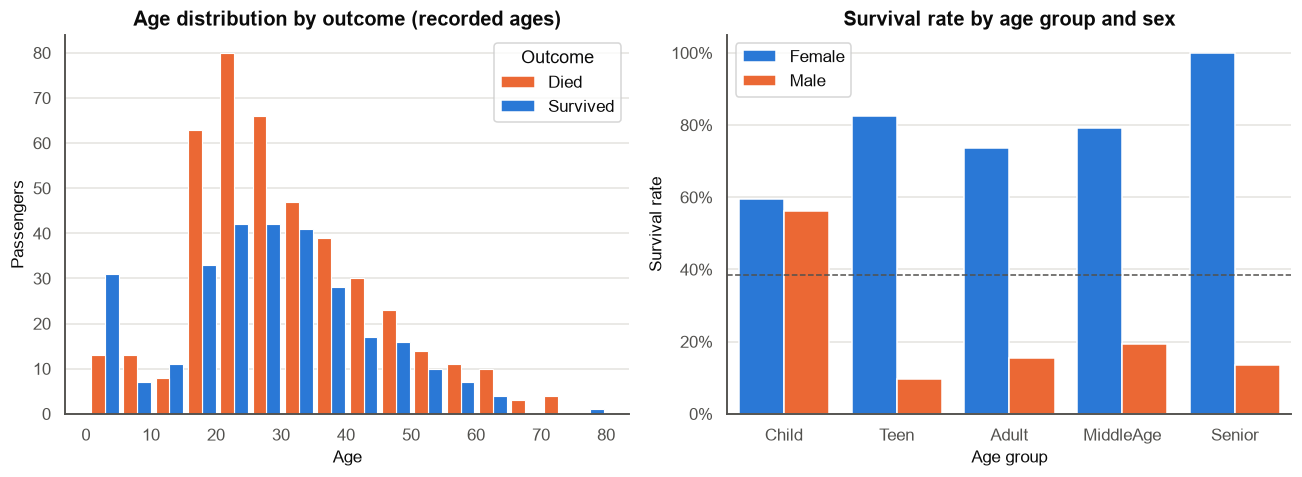

SexLabel,Female,Male
AgeGroup,,
Child,0.594,0.561
Teen,0.826,0.095
Adult,0.736,0.156
MiddleAge,0.793,0.194
Senior,1.000,0.136


In [18]:

known_age = df[~df["AgeWasMissing"]]
print(f"Passengers with a recorded age: {len(known_age)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))


sns.histplot(data=known_age, x="Age", hue="Outcome", bins=16,
             hue_order=["Died", "Survived"], palette=OUTCOME_COLORS,
             multiple="dodge", shrink=0.85, alpha=1, edgecolor="white",
             ax=axes[0])
axes[0].set_title("Age distribution by outcome (recorded ages)")
axes[0].set_ylabel("Passengers")


sns.barplot(data=df, x="AgeGroup", y="Survived", hue="SexLabel",
            order=AGE_ORDER, hue_order=SEX_ORDER, palette=SEX_COLORS,
            errorbar=None, saturation=1, ax=axes[1])
axes[1].axhline(BASE, ls="--", lw=1, color=MUTED)
pct_axis(axes[1], 1.05)
axes[1].set_title("Survival rate by age group and sex")
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Survival rate")
axes[1].legend(title="")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_age.png")
plt.show()

df.pivot_table(index="AgeGroup", columns="SexLabel", values="Survived",
               aggfunc="mean", observed=True).reindex(AGE_ORDER).round(3)

**Observation:** the histogram shows one clear age effect: young children
survived more often than they died, while the 20 to 30 range is dominated by
deaths. Split by sex, the picture is sharper. Boys under 13 survived at about
56%, far above adult men (about 16%), which fits a "women and children first"
pattern. For women, survival stayed high at every age. Age matters, but mainly
for males, and the effect is much smaller than sex or class.

### 3f. Supporting variable: fare

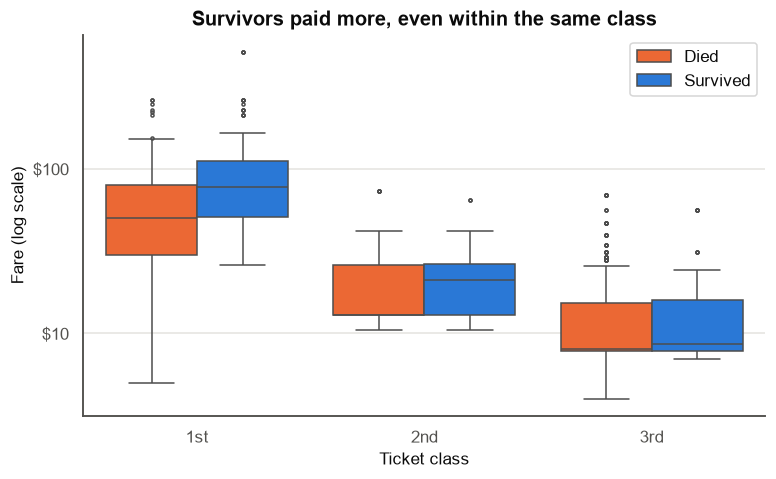

Outcome,Died,Survived
Class,,
1st,44.75,77.96
2nd,13.00,21.00
3rd,8.05,8.52


In [19]:
paid = df[df["Fare"] > 0]

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=paid, x="Class", y="Fare", hue="Outcome", order=CLASS_ORDER,
            hue_order=["Died", "Survived"], palette=OUTCOME_COLORS,
            fliersize=2, linewidth=1, saturation=1, ax=ax)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax.set_title("Survivors paid more, even within the same class")
ax.set_xlabel("Ticket class")
ax.set_ylabel("Fare (log scale)")
ax.legend(title="")
fig.savefig(FIG_DIR / "05_fare.png")
plt.show()

df.pivot_table(index="Class", columns="Outcome", values="Fare",
               aggfunc="median").round(2)

**Observation:** the median fare of survivors (26.00) is about 2.5 times that
of passengers who died (10.50), but most of that is simply class. The box plot
separates the two: inside first class, survivors still paid more (median 77.96
versus 44.75). The gap is smaller in second class (21.00 versus 13.00) and
nearly disappears in third class (8.52 versus 8.05).
Fare mostly acts as a stand-in for class and cabin location.

### 3g. Supporting variable: family size

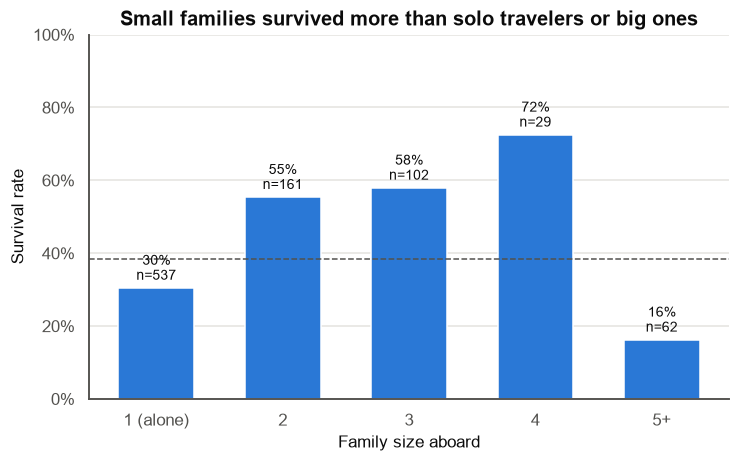

,mean,size
FamilyBand,,
1 (alone),0.304,537
2,0.553,161
3,0.578,102
4,0.724,29
5+,0.161,62


In [20]:

df["FamilyBand"] = pd.cut(df["FamilySize"], bins=[0, 1, 2, 3, 4, 20],
                          labels=["1 (alone)", "2", "3", "4", "5+"])
fam = df.groupby("FamilyBand", observed=True)["Survived"].agg(
    ["mean", "size"])

fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(fam.index.astype(str), fam["mean"], color=BLUE, width=0.6)
label_bars(ax, counts=fam["size"].tolist())
ax.axhline(BASE, ls="--", lw=1, color=MUTED)
pct_axis(ax, 1.0)
ax.set_title("Small families survived more than solo travelers or big ones")
ax.set_xlabel("Family size aboard")
ax.set_ylabel("Survival rate")
fig.savefig(FIG_DIR / "06_family.png")
plt.show()

fam.round(3)

**Observation:** survival follows an upside-down U. Passengers traveling alone
(30.4%, the largest group at 537) and families of five or more (16.1%) did
worst, while families of two to four did best (55% to 72%). A likely reason is
that many solo travelers were third-class men, and large families were mostly
third class and harder to keep together during evacuation.

### 3h. Supporting variable: port of embarkation

C:\Users\Travis\AppData\Local\Temp\ipykernel_44112\3459431959.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  port_rate = df.groupby("Port")["Survived"].agg(["mean", "size"])


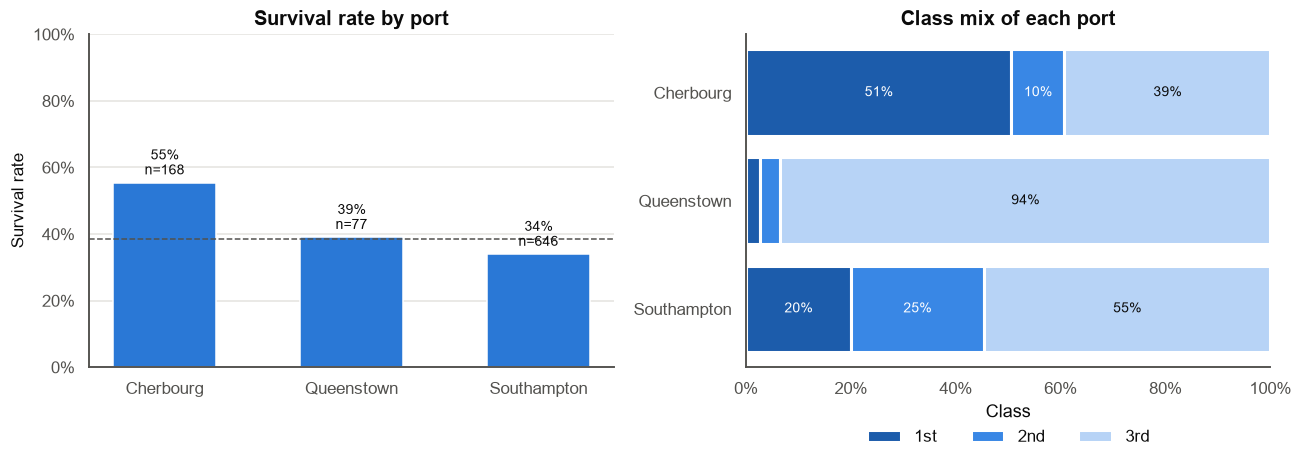

,mean,size
Port,,
Cherbourg,0.554,168
Queenstown,0.390,77
Southampton,0.339,646


In [21]:

port_rate = df.groupby("Port")["Survived"].agg(["mean", "size"])
port_rate = port_rate.reindex(PORT_ORDER)
mix = pd.crosstab(df["Port"], df["Class"], normalize="index")
mix = mix.reindex(index=PORT_ORDER, columns=CLASS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(port_rate.index, port_rate["mean"], color=BLUE, width=0.55)
label_bars(axes[0], counts=port_rate["size"].tolist())
axes[0].axhline(BASE, ls="--", lw=1, color=MUTED)
pct_axis(axes[0], 1.0)
axes[0].set_title("Survival rate by port")
axes[0].set_ylabel("Survival rate")


left = np.zeros(len(mix))
shades = {"1st": "#1c5cab", "2nd": "#3987e5", "3rd": "#b7d3f6"}
for cls in CLASS_ORDER:
    axes[1].barh(mix.index, mix[cls], left=left, color=shades[cls],
                 edgecolor="white", linewidth=2, label=cls)
    for y, (l, w) in enumerate(zip(left, mix[cls])):
        if w > 0.06:
            axes[1].text(l + w / 2, y, f"{w:.0%}", ha="center", va="center",
                         fontsize=9, color="white" if cls != "3rd" else INK)
    left += mix[cls].to_numpy()
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_xlim(0, 1)
axes[1].invert_yaxis()
axes[1].set_title("Class mix of each port")
axes[1].legend(title="Class", ncol=3, loc="lower center",
               bbox_to_anchor=(0.5, -0.28), frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_port.png")
plt.show()

port_rate.round(3)

**Observation:** Cherbourg passengers survived at 55.4%, compared with 39.0%
for Queenstown and 33.9% for Southampton. The class mix explains most of this. About half of
Cherbourg's passengers (51%) were first class, compared with 20% at
Southampton. Queenstown is the interesting exception: it was 94% third class
yet sat near the overall rate, and it also had the highest share of women
(47% versus 32% at Southampton), so sex is likely lifting it. Port looks like a signal but is mostly a proxy for class, which is
a good reminder that a chart of one variable can mislead when another variable
is doing the work.

### 3i. Correlation overview

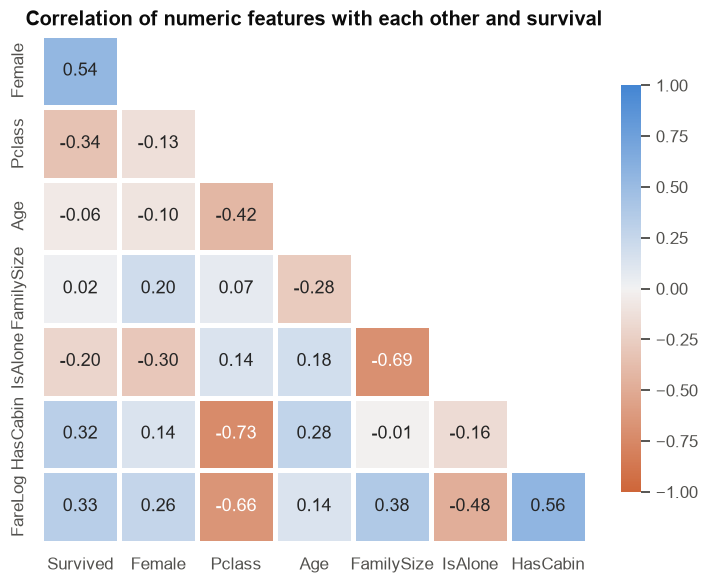

Female        0.54
Pclass       -0.34
FareLog       0.33
HasCabin      0.32
IsAlone      -0.20
Age          -0.06
FamilySize    0.02
Name: Survived, dtype: float64

In [22]:

num = df.assign(Female=(df["Sex"] == "female").astype(int))[
    ["Survived", "Female", "Pclass", "Age", "FamilySize", "IsAlone",
     "HasCabin", "FareLog"]]
corr = num.corr().round(2)

mask = np.triu(np.ones_like(corr, dtype=bool), k=0)
plot_corr = corr.iloc[1:, :-1]
plot_mask = mask[1:, :-1]

fig, ax = plt.subplots(figsize=(8, 6))
cmap = sns.diverging_palette(25, 250, s=80, l=55, as_cmap=True)
sns.heatmap(plot_corr, mask=plot_mask, annot=True, fmt=".2f", cmap=cmap,
            center=0,
            vmin=-1, vmax=1, linewidths=2, linecolor="white",
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.grid(False)
ax.set_title("Correlation of numeric features with each other and survival")
fig.savefig(FIG_DIR / "08_corr.png")
plt.show()

corr["Survived"].drop("Survived").sort_values(key=abs, ascending=False)

**Observation:** the strongest correlation with survival is being female
(+0.54), followed by ticket class (-0.34, since a higher class number means a
lower class), log fare (+0.33), and having a recorded cabin (+0.32). Class,
cabin, and fare are strongly correlated with each other (class with cabin at
-0.73 and with log fare at -0.66), which confirms they mostly measure the same thing:
wealth and location on the ship. Age and family size have weak linear
correlations because their effects are not straight lines, as the charts in
3e and 3g showed.

---
# Step 4: Report

### Results against the hypothesis

In [23]:

f_rate = sex_rate.loc["Female", "mean"]
m_rate = sex_rate.loc["Male", "mean"]
report = pd.DataFrame([
    {"ID": "H1", "Claim": "Women survived more than men",
     "Evidence": f"Female {f_rate:.1%} vs male {m_rate:.1%}; V = 0.54",
     "Result": "Supported"},
    {"ID": "H2", "Claim": "Survival falls from 1st to 3rd class",
     "Evidence": " / ".join(f"{c} {r:.1%}" for c, r in
                            class_rate["mean"].items()) + "; V = 0.34",
     "Result": "Supported"},
    {"ID": "H3", "Claim": "Sex gap holds inside every class",
     "Evidence": "Women ahead in all 3 classes; 3rd-class women (50%) "
                 "beat 1st-class men (37%)",
     "Result": "Supported"},
])


for _, row in report.iterrows():
    print(f"{row['ID']}  {row['Result'].upper()}: {row['Claim']}")
    print(f"    Evidence: {row['Evidence']}")
    print()

H1  SUPPORTED: Women survived more than men
    Evidence: Female 74.2% vs male 18.9%; V = 0.54

H2  SUPPORTED: Survival falls from 1st to 3rd class
    Evidence: 1st 63.0% / 2nd 47.3% / 3rd 24.2%; V = 0.34

H3  SUPPORTED: Sex gap holds inside every class
    Evidence: Women ahead in all 3 classes; 3rd-class women (50%) beat 1st-class men (37%)



### Summary of findings

1. **Sex was the strongest factor.** Women survived at 74.2% versus 18.9% for
   men. Sex had the largest effect size of any variable tested.
2. **Class was the second strongest factor.** Survival dropped from 63.0% in
   first class to 24.2% in third class.
3. **The two factors combine.** First-class women nearly all survived (97%),
   while second- and third-class men almost all died (14% to 16%). Even the
   worst-off women out-survived the best-off men.
4. **Age mattered mainly for males.** Boys under 13 survived at about 56%,
   while adult men survived at about 16%.
5. **Some apparent effects are really class.** Higher fares and the Cherbourg
   port both show higher survival, but both mostly reflect a larger share of
   first-class passengers.
6. **Traveling alone or in a large family was risky.** Solo travelers (30%)
   and families of five or more (16%) did worse than small families (55% to
   72%).

### Conclusion

The data supports the hypothesis. Women and passengers in higher ticket
classes survived at much higher rates than men and passengers in lower
classes, and the chi-square tests show these gaps are far too large to be
chance. The analysis adds an important detail the original hypothesis did not
state: sex outweighs class, so the full ordering runs from upper-class women,
through lower-class women and upper-class men, down to lower-class men.

### Limitations

- These are associations, not proof of cause. The charts describe who
  survived but cannot show why.
- 20% of ages were imputed from group medians, so age results rely mainly on
  the 714 recorded ages.
- The analysis set is 891 of the roughly 2,200 people aboard, so the rates
  describe this sample rather than every passenger and crew member.
- Some groups are small (for example 26 seniors and 44 teens), so their rates
  are less reliable.



In [24]:
# Save the analysis set.
df.to_csv("titanic_analysis.csv", index=False)
print("Saved titanic_analysis.csv with shape", df.shape)
print("Figures saved:")
for png in sorted(FIG_DIR.glob("*.png")):
    print("  ", png.name)

Saved titanic_analysis.csv with shape (891, 26)
Figures saved:
   01_overall.png
   02_sex_class.png
   03_heatmap.png
   04_age.png
   05_fare.png
   06_family.png
   07_port.png
   08_corr.png
